In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import numpy as np 
#from bias_utils import *


import constants as c 
import helpers as h 
from logger import setup_logger 
log = setup_logger("311-biases")
log.setLevel("INFO")
log.info("Modules loaded.")

h.latex(True)

2026-02-06 13:16:25 - 311-biases - INFO - Modules loaded.
2026-02-06 13:16:25 - analysis-helpers - INFO - Enabling LaTeX for matplotlib.


In [2]:
analysis_df = pd.read_csv(c.CURRENT_DF)
analysis_df = h.add_covariate_cols(analysis_df)
analysis_df = h.add_estimate_cols(analysis_df)
analysis_df = h.add_demo_cols(analysis_df)


2026-02-06 13:16:25 - analysis-helpers - INFO - Found 192 tracts with at least one FloodNet sensor.
2026-02-06 13:16:25 - analysis-helpers - INFO - Found 2171 311 requests.
2026-02-06 13:16:25 - analysis-helpers - INFO - Found 878 tracts with at least one 311 report.
2026-02-06 13:16:25 - analysis-helpers - INFO - Found 1001 tracts with no DEP flooding.
2026-02-06 13:16:25 - analysis-helpers - INFO - Found 176 tracts with confirmed flooding.
2026-02-06 13:16:25 - analysis-helpers - INFO - Found 298 tracts with above threshold (0.0055220865623846) flooding.
2026-02-06 13:16:25 - analysis-helpers - INFO - Found 342 tracts with confirmed or above threshold flooding.
2026-02-06 13:16:25 - analysis-helpers - INFO - Added fraction white (frac_white) column.
2026-02-06 13:16:25 - analysis-helpers - INFO - Added fraction black (frac_black) column.
2026-02-06 13:16:25 - analysis-helpers - INFO - Added fraction hispanic (frac_hispanic) column.
2026-02-06 13:16:25 - analysis-helpers - INFO - Adde

In [3]:
analysis_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2325 entries, 0 to 2324
Data columns (total 68 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   BoroName                                      2325 non-null   object 
 1   BoroCT2020                                    2325 non-null   int64  
 2   NTAName                                       2325 non-null   object 
 3   CDTANAME                                      2325 non-null   object 
 4   PUMA                                          2325 non-null   int64  
 5   empirical_estimate                            2319 non-null   float64
 6   p_y                                           2325 non-null   float64
 7   p_y_CI_lower                                  2325 non-null   float64
 8   p_y_CI_upper                                  2325 non-null   float64
 9   n_images_by_area                              2325 non-null   i

# basic exploratory analysis

In [4]:
pd.set_option('display.max_columns', 500)

analysis_df.head()


,BoroName,BoroCT2020,NTAName,CDTANAME,PUMA,empirical_estimate,p_y,p_y_CI_lower,p_y_CI_upper,n_images_by_area,empirical_estimate_p_alop,at_least_one_positive_image_by_area,at_least_one_positive_image_by_area_CI_lower,at_least_one_positive_image_by_area_CI_upper,total_population,nhl_white_alone,nhl_black_alone,hispanic_alone,nhl_asian_alone,n_children,n_elderly,total_households,num_households_with_internet,num_households_with_smartphone,median_household_income,num_high_school_graduates,num_bachelors_degree,num_graduate_degree,num_limited_english_speaking_households,ft_elevation_min,ft_elevation_max,ft_elevation_mean,area,n_floodnet_sensors,n_catch_basins,catch_basin_density,cb_days_clogged,has_clogged_cb_complaint,cb_avg_resolution_time,dep_moderate_1_area,dep_moderate_1_frac,dep_moderate_2_area,dep_moderate_2_frac,GEOID,sewer_backup_311c,street_flooding_311c,catch_basin_clogged/flooding_311c,manhole_overflow_311c,highway_flooding_311c,any_sensors,n_311_reports,any_311_report,no_dep_flooding,confirmed_flooding,above_thres,confirmed_or_above_thres,frac_white,frac_black,frac_hispanic,frac_asian,frac_hs,frac_bachelors,frac_grad,frac_children,frac_elderly,frac_internet,frac_smartphone,frac_limited_english
0,Manhattan,1000100,The Battery-Governors Island-Ellis Island-Libe...,MN01 Financial District-Tribeca (CD 1 Equivalent),4121,NaN,0.050211,2.158959e-314,1.000000,0,NaN,0.000000,0.000000,0.000000,0,0,0,0,0,0,0,0,0,0,NaN,0,0,0,0,0.0,19.0,8.153329,1.842909e+06,0.0,0.0,0.000000,0.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,36061000100,0,0,0,0,0,False,0,False,True,False,True,True,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Manhattan,1001401,Lower East Side,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.0,0.001444,9.342801e-06,0.009392,259,0.0,0.210764,0.002417,0.913187,3395,2371,65,370,258,328,1311,1761,1471,1385,94076.0,398,930,790,100,24.0,43.0,34.847163,1.006117e+06,0.0,13.0,0.000013,0.0,0,0.000000,0.000000,0.000000,0.000000,0.000000,36061001401,1,0,0,0,0,False,1,True,True,False,False,False,0.698380,0.019146,0.108984,0.075994,0.117231,0.273932,0.232695,0.096613,0.386156,0.835321,0.786485,0.056786
2,Manhattan,1001402,Lower East Side,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.0,0.000461,1.630542e-06,0.003213,705,0.0,0.183762,0.001149,0.896538,3449,1008,249,813,1166,249,910,1807,1520,1584,50347.0,311,1014,360,647,13.0,42.0,27.553037,1.226207e+06,0.0,44.0,0.000036,0.0,0,0.000000,3811.632650,0.003108,7439.195282,0.006067,36061001402,0,0,0,0,0,False,0,False,False,False,False,False,0.292259,0.072195,0.235720,0.338069,0.090171,0.293998,0.104378,0.072195,0.263845,0.841173,0.876591,0.358052
3,Manhattan,1001800,Lower East Side,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.0,0.000220,2.648354e-06,0.001355,1783,0.0,0.228073,0.004711,0.910932,6702,2280,410,905,2921,336,1408,2979,2647,2731,79973.0,536,2252,557,428,8.0,45.0,36.394639,2.399278e+06,0.0,94.0,0.000039,8.0,1,2.666667,0.000000,0.000000,0.000000,0.000000,36061001800,0,0,0,0,0,False,0,False,True,False,False,False,0.340197,0.061176,0.135034,0.435840,0.079976,0.336019,0.083110,0.050134,0.210087,0.888553,0.916751,0.143672
4,Manhattan,1002201,Lower East Side,MN03 Lower East Side-Chinatown (CD 3 Equivalent),4103,0.0,0.001083,1.971842e-05,0.006184,422,0.0,0.262862,0.008287,0.927023,6437,1755,1453,1983,977,988,1281,3011,2232,2662,38594.0,1283,968,580,368,9.0,28.0,17.288704,1.740175e+06,0.0,34.0,0.000020,0.0,1,0.000000,14976.604512,0.008606,16900.033063,0.009712,36061002201,1,0,0,0,0,False,1,True,False,False,False,False,0.272643,0.225726,0.308063,0.151779,0.199316,0.150381,0.090104,0.153488,0.199006,0.741282,0.884092,0.122219


In [5]:

# drop rows with 0 population 
analysis_df = analysis_df[analysis_df['total_population'] > 0]

In [6]:
# log total population and median household income 
analysis_df['total_population'] = np.log(analysis_df['total_population'])
analysis_df['median_household_income'] = np.log(analysis_df['median_household_income'])

In [7]:
vars = ['frac_white', 'frac_black', 'frac_hispanic', 'frac_asian', 'median_household_income', 'frac_hs', 'frac_bachelors', 'frac_grad', 'frac_internet', 'frac_smartphone', 'frac_limited_english', 'frac_children', 'frac_elderly', 'total_population']

analysis_df['median_household_income'] = analysis_df['median_household_income'].replace(-666666666, np.nan)

to_standardize =[ 'frac_hs', 'frac_bachelors', 'frac_grad', 'frac_internet', 'frac_smartphone', 'frac_limited_english', 'frac_children', 'frac_elderly', 'frac_white', 'frac_black', 'frac_hispanic', 'frac_asian', 'median_household_income', 'total_population']
for var in to_standardize:
    analysis_df[var] = (analysis_df[var] - analysis_df[var].mean()) / analysis_df[var].std()

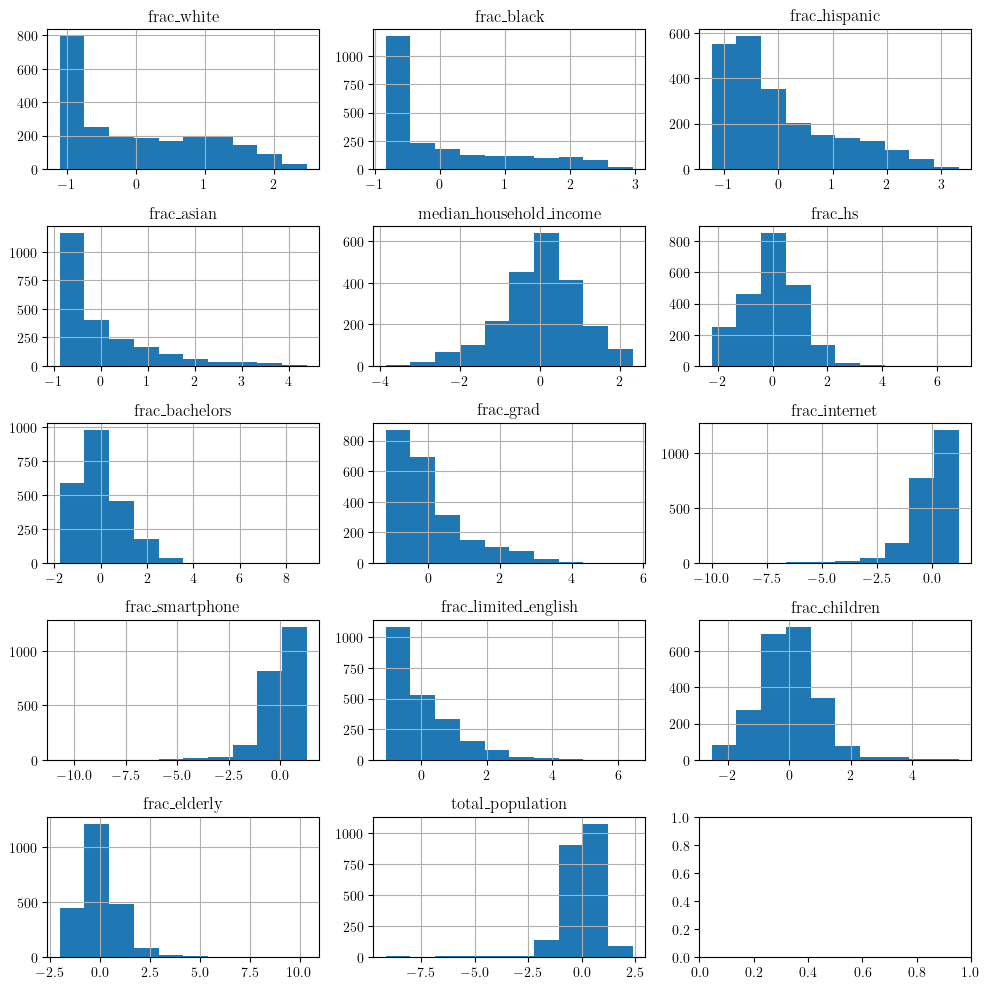

In [8]:
# make small histograms side by side for each var in vars 
fig, axs = plt.subplots(5, 3, figsize=(10, 10))
for i, var in enumerate(vars):
    ax = axs[i//3, i%3]
    analysis_df[var].hist(ax=ax)
    ax.set_title(var)
plt.tight_layout()



In [9]:
analysis_df['any_311_report'] = analysis_df['any_311_report'].astype(int)  


def get_bias_metrics(model, var):
    """
    Extract bias metrics from a fitted statsmodels model for a given variable.
    
    Parameters:
    -----------
    model : statsmodels.discrete.discrete_model.BinaryResultsWrapper
        Fitted logistic regression model
    var : str
        Name of the variable to extract metrics for
        
    Returns:
    --------
    pd.DataFrame
        Single row dataframe with metrics for the variable
    """
    params = model.params
    conf_int = model.conf_int()
    
    return pd.DataFrame({
        'variable': [var],
        'mean': [params[var]],
        'ci_lower': [conf_int.loc[var, 0]],
        'ci_upper': [conf_int.loc[var, 1]],
        'p_value': [model.pvalues[var]],
        'std_err': [model.bse[var]]
    })

def analyze_biases(data, outcome='any_311_report', predictor='p_y', 
                  variables=['frac_white', 'frac_black', 'frac_hispanic', 
                           'frac_asian', 'median_household_income', 'frac_hs', 'frac_bachelors', 'frac_grad', 'frac_internet', 'frac_smartphone', 'frac_limited_english']):
    """
    Analyze biases across multiple variables using logistic regression.
    
    Parameters:
    -----------
    data : pd.DataFrame
        Input dataset
    outcome : str
        Name of binary outcome variable
    predictor : str
        Name of main predictor variable
    variables : list
        List of variables to analyze for bias
        
    Returns:
    --------
    pd.DataFrame
        Compiled bias metrics for all variables
    """
    bias_df = pd.DataFrame()
    
    for var in variables:
        # Standardize continuous variables
        data_std = data.copy()
        data_std[var] = (data_std[var] - data_std[var].mean()) / data_std[var].std()
        
        # Fit model with interaction
        formula = f'{outcome} ~ {predictor} + {var}'  # Simplified model without interaction
        try:
            model = sm.Logit.from_formula(formula, data=data_std).fit(
            )
            bias_metrics = get_bias_metrics(model, var)
            bias_df = pd.concat([bias_df, bias_metrics], ignore_index=True)
        except Exception as e:
            print(f"Error fitting model for {var}: {str(e)}")
            
    return bias_df

# Example usage:
# bias_results = analyze_biases(d_income)

bias_results = analyze_biases(analysis_df, outcome='any_311_report', variables=vars)
confirmed_bias_results = analyze_biases(analysis_df, outcome='any_311_report', variables=vars, predictor='confirmed_or_above_thres')



Optimization terminated successfully.
         Current function value: 0.648578
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.649853
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.641771
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.649048
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.644251
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.649624
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.649426
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.649868
         Iterations 7
Optimization terminated successfully.
         Current function value: 0.648955
         Iterations 8
Optimization terminated successfully.
         Current function value: 0.649221
  

In [10]:
# replace variable names 
mapping = {
    'frac_white': 'Fraction White',
    'frac_black': 'Fraction Black',
    'frac_hispanic': 'Fraction Hispanic',
    'frac_asian': 'Fraction Asian',
    'median_household_income': '$log($Median Household Income$)$',
    'frac_hs': 'Fraction High School Graduates',
    'frac_bachelors': 'Fraction Bachelor\'s Degree',
    'frac_grad': 'Fraction Graduate Degree',
    'frac_internet': 'Fraction Households with Internet',
    'frac_smartphone': 'Fraction Households with Smartphone',
    'frac_limited_english': 'Fraction Households with Limited English',
    'frac_children': r'Fraction Children ($<$ 18 yrs)',
    'frac_elderly': r'Fraction Elderly ( $\leq$ 65 years)',
    'total_population': '$log($Total Population$)$',
}

bias_results['variable'] = bias_results['variable'].map(mapping)
confirmed_bias_results['variable'] = confirmed_bias_results['variable'].map(mapping)

bias_results = bias_results.set_index('variable')
confirmed_bias_results = confirmed_bias_results.set_index('variable')

In [11]:
def plot_CIs_covariates(CIs_df, crop_plots=True, ax=None, figsize=(6, 6),
                        covariate_names=None, show=True, ylabel_size=16,
                        xlabel_size=12,
                        color_CIs_by_significance=True, fill_between=False, horizontal_lines=True):
    
    if ax is None: fig, ax = plt.subplots(figsize=figsize)
    
    CIs_df = CIs_df.replace({'-':np.nan}).dropna()
    if covariate_names is None: covariate_names = CIs_df.index.values
    
    estimates = CIs_df.loc[covariate_names, 'mean'].values
    UB = CIs_df.loc[covariate_names, 'ci_upper'].values
    LB = CIs_df.loc[covariate_names, 'ci_lower'].values
    CIs = np.vstack([estimates-LB, UB-estimates])

    
    # Get p-values from dataframe
    p_values = CIs_df['p_value'].values

    #Collect colors:
    if color_CIs_by_significance:
        colors = ['red' if ub < 0 else ('blue' if lb > 0 else 'grey')
                 for ub, lb in list(zip(UB, LB))]

        # color in if p-value is significant, else only color the edge 
        mfcs = ['none']*len(estimates)
        for i, p in enumerate(p_values):
            if p < 0.05:
                mfcs[i] = colors[i]
                
    else:
        colors = ['black']*len(estimates)

    #Plot:
    for estimate, name, CI, color, mfc, p_value in zip(estimates[::-1],
                                         covariate_names[::-1],
                                         CIs[::, ::-1].T,
                                         colors[::-1],
                                            mfcs[::-1],
                                         p_values[::-1]):
        _ = ax.errorbar(x=estimate,
                        y=name,
                        xerr=CI.reshape(2,1),
                        ecolor=color,
                        capsize=5,
                        linestyle='None',
                        linewidth=1.5,
                        marker="d",
                        markersize=5,
                        mfc=mfc,
                        mec=color)
        print(f"{name}: {estimate:.2f} ({estimate-CI[0]:.2f}, {estimate+CI[1]:.2f}). Significance: {p_value:.3f}")

    ax.tick_params(axis='y', labelsize=ylabel_size)
    ax.tick_params(axis='x', labelsize=xlabel_size)
    #Grids:
    xlim = ax.get_xlim()
    _ = ax.axvline(0, linestyle='--', color='black', alpha=0.75, zorder=-1, linewidth=1.)

    if fill_between:
        _ = ax.fill_between(np.linspace(xlim[0], xlim[1], 1000, endpoint=True), -0.5, 1.5, alpha=.4, color='lightgrey', linewidth=0)
        _ = ax.fill_between(np.linspace(xlim[0], xlim[1], 1000, endpoint=True), 6.5, 8.5, alpha=.4, color='lightgrey', linewidth=0)
        _ = ax.fill_between(np.linspace(xlim[0], xlim[1], 1000, endpoint=True), 10.5, 14.5, alpha=.4, color='lightgrey', linewidth=0)
    if horizontal_lines:
        for y, c in enumerate(colors[::-1]):
            _ = ax.hlines(y=y, xmin=-3, xmax=3, linestyle='--', linewidth=0.5, alpha=0.5, color='grey')
    _ = ax.set_xlim(xlim)
    _ = ax.set_ylim(-0.5, len(estimates)-0.5)

    # x axis label
    _ = ax.set_xlabel(r'$\beta_d$', fontsize=16)
            
    if show: plt.show()
        
    return ax

In [12]:
bias_results

,mean,ci_lower,ci_upper,p_value,std_err
variable,,,,,
Fraction White,0.108632,0.022472,0.194793,1.346830e-02,0.043960
Fraction Black,0.027019,-0.059183,0.113221,5.389994e-01,0.043981
Fraction Hispanic,-0.276851,-0.368743,-0.184959,3.527634e-09,0.046885
Fraction Asian,0.087181,0.001881,0.172482,4.515695e-02,0.043521
$log($Median Household Income$)$,0.195887,0.105647,0.286126,2.094471e-05,0.046041
Fraction High School Graduates,0.052166,-0.034148,0.138480,2.361971e-01,0.044039
Fraction Bachelor's Degree,0.066457,-0.019462,0.152377,1.295210e-01,0.043837
Fraction Graduate Degree,-0.024472,-0.111130,0.062185,5.799246e-01,0.044214
Fraction Households with Internet,0.057845,-0.030406,0.146097,1.989061e-01,0.045027


$log($Total Population$)$: 0.08 (-0.01, 0.17). Significance: 0.066
Fraction Elderly ( $\leq$ 65 years): -0.01 (-0.10, 0.07). Significance: 0.761
Fraction Children ($<$ 18 yrs): 0.10 (0.02, 0.19). Significance: 0.020
Fraction Households with Limited English: -0.06 (-0.15, 0.03). Significance: 0.180
Fraction Households with Smartphone: -0.03 (-0.12, 0.06). Significance: 0.484
Fraction Households with Internet: 0.06 (-0.03, 0.15). Significance: 0.199
Fraction Graduate Degree: -0.02 (-0.11, 0.06). Significance: 0.580
Fraction Bachelor's Degree: 0.07 (-0.02, 0.15). Significance: 0.130
Fraction High School Graduates: 0.05 (-0.03, 0.14). Significance: 0.236
$log($Median Household Income$)$: 0.20 (0.11, 0.29). Significance: 0.000
Fraction Asian: 0.09 (0.00, 0.17). Significance: 0.045
Fraction Hispanic: -0.28 (-0.37, -0.18). Significance: 0.000
Fraction Black: 0.03 (-0.06, 0.11). Significance: 0.539
Fraction White: 0.11 (0.02, 0.19). Significance: 0.013


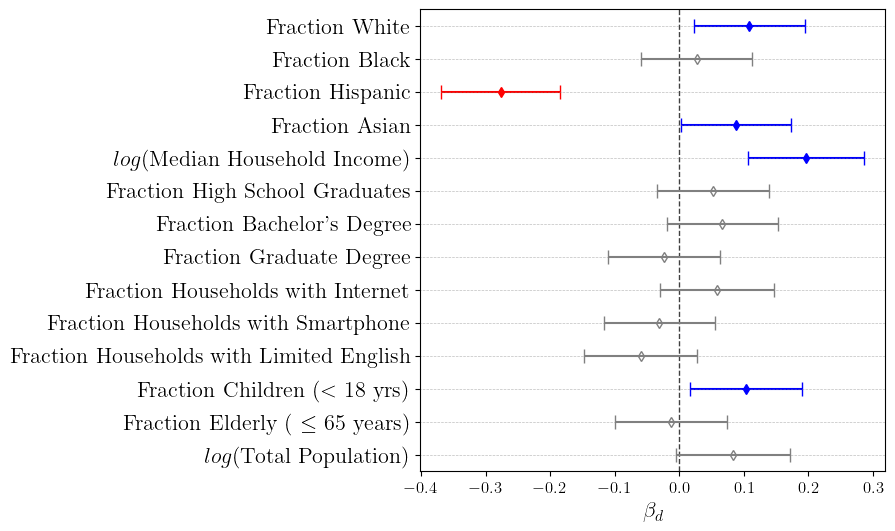

In [13]:
fig = plot_CIs_covariates(bias_results, show=False)
plt.savefig(f'{c.PAPER_PATH}/figures/bias.pdf', bbox_inches='tight', dpi=300)
# save figure 



In [14]:
confirmed_bias_results

,mean,ci_lower,ci_upper,p_value,std_err
variable,,,,,
Fraction White,0.091818,0.005248,0.178389,3.763828e-02,0.044170
Fraction Black,0.041689,-0.044497,0.127874,3.431013e-01,0.043973
Fraction Hispanic,-0.265064,-0.356941,-0.173187,1.563422e-08,0.046877
Fraction Asian,0.077734,-0.007793,0.163260,7.485207e-02,0.043637
$log($Median Household Income$)$,0.179187,0.089878,0.268495,8.409480e-05,0.045567
Fraction High School Graduates,0.057815,-0.028756,0.144386,1.905556e-01,0.044170
Fraction Bachelor's Degree,0.062953,-0.023158,0.149064,1.518958e-01,0.043935
Fraction Graduate Degree,-0.034899,-0.121974,0.052176,4.321389e-01,0.044427
Fraction Households with Internet,0.051846,-0.036321,0.140013,2.490943e-01,0.044984


$log($Total Population$)$: 0.09 (0.00, 0.18). Significance: 0.049
Fraction Elderly ( $\leq$ 65 years): -0.01 (-0.10, 0.07). Significance: 0.763
Fraction Children ($<$ 18 yrs): 0.12 (0.03, 0.20). Significance: 0.008
Fraction Households with Limited English: -0.06 (-0.15, 0.03). Significance: 0.175
Fraction Households with Smartphone: -0.03 (-0.12, 0.06). Significance: 0.485
Fraction Households with Internet: 0.05 (-0.04, 0.14). Significance: 0.249
Fraction Graduate Degree: -0.03 (-0.12, 0.05). Significance: 0.432
Fraction Bachelor's Degree: 0.06 (-0.02, 0.15). Significance: 0.152
Fraction High School Graduates: 0.06 (-0.03, 0.14). Significance: 0.191
$log($Median Household Income$)$: 0.18 (0.09, 0.27). Significance: 0.000
Fraction Asian: 0.08 (-0.01, 0.16). Significance: 0.075
Fraction Hispanic: -0.27 (-0.36, -0.17). Significance: 0.000
Fraction Black: 0.04 (-0.04, 0.13). Significance: 0.343
Fraction White: 0.09 (0.01, 0.18). Significance: 0.038


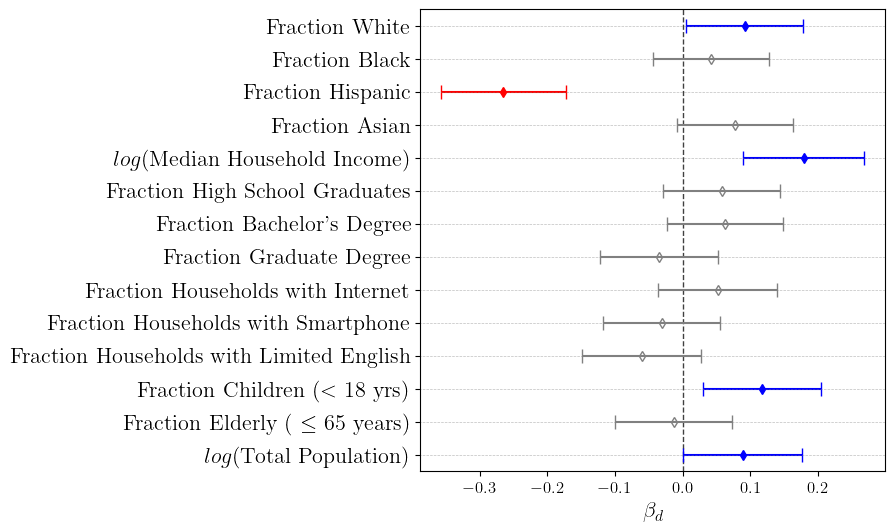

In [15]:
fig_confirmed = plot_CIs_covariates(confirmed_bias_results, show=False)
plt.savefig(f'{c.PAPER_PATH}/figures/confirmed_bias.pdf', bbox_inches='tight', dpi=300)
# save figure 
